In [96]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import Aer
from matplotlib.animation import FuncAnimation

In [97]:
def get_increment_gate(n):
    """Creates a gate that adds 1 to a binary register."""
    qr = QuantumRegister(n)
    qc = QuantumCircuit(qr)
    for i in range(n - 1, 0, -1):
        qc.mcx(list(range(i)), i)
    qc.x(0)
    return qc.to_gate(label="INC")

def get_decrement_gate(n):
    """Creates a gate that subtracts 1 from a binary register."""
    qr = QuantumRegister(n)
    qc = QuantumCircuit(qr)
    qc.x(range(n))
    qc.append(get_increment_gate(n), range(n))
    qc.x(range(n))
    return qc.to_gate(label="DEC")

In [98]:
def run_quantum_walk(num_steps, n_qubits=7):
    # 1. Setup
    qr = QuantumRegister(n_qubits + 1)
    cr = ClassicalRegister(n_qubits)
    qc = QuantumCircuit(qr, cr)
    
    # 2. Start in the middle (Position 64) to avoid boundary issues
    qc.x(n_qubits - 1) 
    
    # 3.1 Symmetric Coin
    qc.h(n_qubits)
    qc.s(n_qubits)

    # 3.2 Asymmetric Coin
    # qc.h(n_qubits)
    
    # 4. Walk Loop (Using the INC/DEC gates from before)
    inc = get_increment_gate(n_qubits).control(1)
    dec = get_decrement_gate(n_qubits).control(1)
    
    for _ in range(num_steps):
        qc.h(n_qubits)
        qc.append(inc, [n_qubits] + list(range(n_qubits)))
        qc.x(n_qubits)
        qc.append(dec, [n_qubits] + list(range(n_qubits)))
        qc.x(n_qubits)
        
    qc.measure(range(n_qubits), range(n_qubits))
    
    # 5. Execute
    backend = Aer.get_backend('qasm_simulator')
    result = backend.run(qc.decompose(), shots=1024).result()
    return result.get_counts()

def classical_walk(steps, walkers):
    # Each walker starts at position 0
    positions = np.zeros(walkers)
    
    for _ in range(steps):
        # Generate random steps: -1 or 1
        steps_taken = np.random.choice([-1, 1], size=walkers)
        positions += steps_taken
        
    return positions

In [99]:
def calculate_std(counts, n_qubits):
    #Calculates the standard deviation of the distribution.
    total_shots = sum(counts.values())
    
    # Convert binary to decimal and center around 0 (subtract 2^(n-1))
    offset = 2**(n_qubits - 1)
    
    # Calculate Mean (mu)
    mu = sum( (int(k, 2) - offset) * (v / total_shots) for k, v in counts.items() )
    
    # Calculate Variance
    var = sum( ((int(k, 2) - offset) - mu)**2 * (v / total_shots) for k, v in counts.items() )
    return np.sqrt(var)

In [100]:
#Main
# Parameters
max_steps = 64
n_qubits = 7  # 128 positions
shots = 1024

quantum_data = []
classical_data = []
q_stds = []
c_stds = []

# Collect data for each time step
for t in range(1, max_steps + 1):
    # 1. Quantum Step
    counts = run_quantum_walk(t, n_qubits) # Use the function from the previous turn
    # Convert counts to a full 128-length probability array
    q_probs = np.zeros(2**n_qubits)
    for k, v in counts.items():
        q_probs[int(k, 2)] = v / shots
    quantum_data.append(q_probs)
    q_stds.append(calculate_std(counts, n_qubits))
    
    # 2. Classical Step
    c_pos = classical_walk(t, shots) # Use the numpy function
    # Center classical walk at the same midpoint (64)
    c_hist, _ = np.histogram(c_pos + 64, bins=range(129), density=True)
    classical_data.append(c_hist)
    c_stds.append(np.std(c_pos))

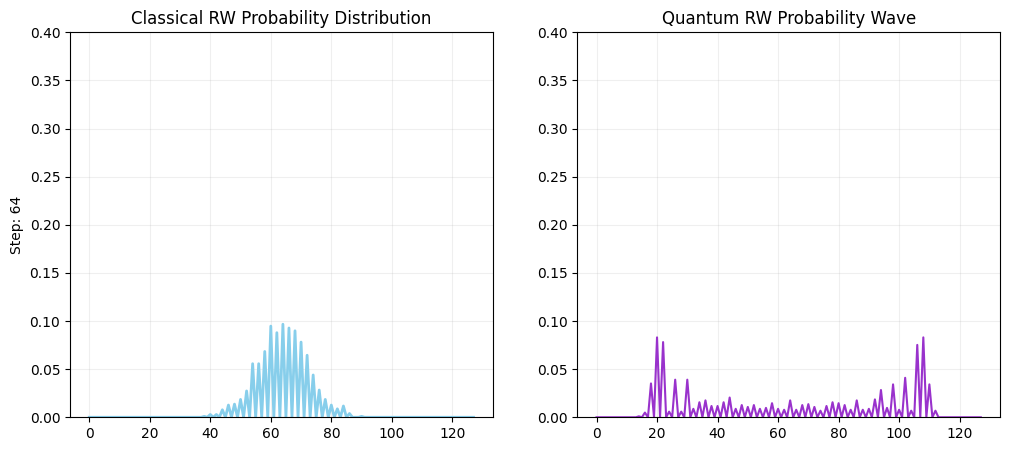

In [101]:
#Animation
#Line instead of bar chart

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
x = np.arange(2**n_qubits)

# Initialize lines
line_class, = ax1.plot(x, classical_data[0], color='skyblue', lw=2, label='Classical')
line_quant, = ax2.plot(x, quantum_data[0], color='darkorchid', lw=1.5, label='Quantum')

# Set consistent styling
ax1.set_title("Classical RW Probability Distribution")
ax2.set_title("Quantum RW Probability Distribution")
ax1.set_ylim(0, 0.4)
ax2.set_ylim(0, 0.4)
ax1.grid(True, alpha=0.2)
ax2.grid(True, alpha=0.2)

def update(frame):
    line_class.set_ydata(classical_data[frame])
    line_quant.set_ydata(quantum_data[frame])
    ax1.set_ylabel(f"Step: {frame+1}")
    return line_class, line_quant

ani = FuncAnimation(fig, update, frames=max_steps, blit=True)
ani.save('CRW-QRW.gif', writer='pillow', fps=10)
plt.show()

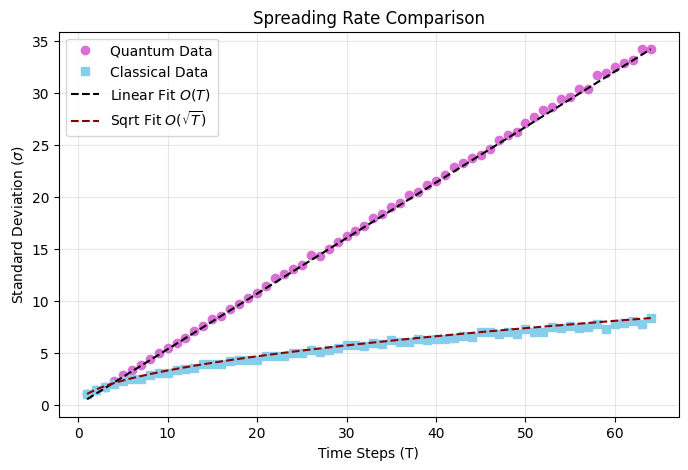

In [120]:
#Standard Deviation Plot

plt.figure(figsize=(8, 5))
t_axis = np.arange(1, max_steps + 1)

# Plot experimental data
plt.plot(t_axis, q_stds, 'o', label='Quantum Data', color='orchid')
plt.plot(t_axis, c_stds, 's', label='Classical Data', color='skyblue')

# Add trendlines to show the math
plt.plot(t_axis, t_axis * (q_stds[-1]/max_steps), '--', color="black", label='Linear Fit $O(T)$')
plt.plot(t_axis, np.sqrt(t_axis) * (c_stds[-1]/np.sqrt(max_steps)), '--', color='darkred', label='Sqrt Fit $O(\sqrt{T})$')

plt.xlabel("Time Steps (T)")
plt.ylabel("Standard Deviation ($\sigma$)")
plt.title("Spreading Rate Comparison")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()